# PyTorch Implementation of VAE

In [7]:
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F


In [8]:
import os

from PIL import Image
from torch.utils.data import Dataset

DEFAULT_EPS = 1e-8
IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg')


class FlatImageDataset(Dataset):
    """Dataset for a flat folder of images (no class subdirectories)."""

    def __init__(self, root: str, transform=None):
        self.root = root
        self.transform = transform
        self.files = sorted(f for f in os.listdir(root) if f.lower().endswith(IMG_EXTENSIONS))

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int) -> torch.Tensor:
        path = os.path.join(self.root, self.files[idx])
        with Image.open(path) as img:
            img = img.convert('RGB')
            if self.transform:
                img = self.transform(img)
        return img


def sigmoid_to_std(sigma: torch.Tensor, use_softplus: bool, eps: float = DEFAULT_EPS) -> torch.Tensor:
    """Convert a sigma/log-variance tensor to standard deviation."""
    if use_softplus:
        return F.softplus(sigma) + eps
    return torch.exp(0.5 * sigma)


def expand_for_sampling(x: torch.Tensor, num_samples: int, input_shape: tuple[int, int, int]) -> torch.Tensor:
    """Expand a batch for repeated sampling."""
    shape_dims = [1] * len(input_shape)
    x_expanded = x.unsqueeze(1).repeat(1, num_samples, *shape_dims)
    return x_expanded.view(-1, *input_shape)


def expand_latent_params(mu: torch.Tensor, std: torch.Tensor, num_samples: int, latent_dim: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Expand latent parameters for repeated sampling."""
    if num_samples == 1:
        return mu, std

    mu_expanded = mu.unsqueeze(1).repeat(1, num_samples, 1).view(-1, latent_dim)
    std_expanded = std.unsqueeze(1).repeat(1, num_samples, 1).view(-1, latent_dim)
    return mu_expanded, std_expanded


def compute_reconstruction_loss(x: torch.Tensor, x_logits: torch.Tensor) -> torch.Tensor:
    """Compute the reconstruction loss."""
    return F.binary_cross_entropy_with_logits(x_logits, x, reduction='sum') / x.size(0)


def compute_kl_loss(mu: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
    """Compute the KL divergence."""
    return 0.5 * torch.sum(mu.pow(2) + sigma.exp() - 1 - sigma, dim=1).mean()


def compute_loss(x: torch.Tensor, x_logits: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute total, reconstruction, and KL losses."""
    loss_recon = compute_reconstruction_loss(x, x_logits)
    loss_kl = compute_kl_loss(mu, sigma)
    return loss_recon + loss_kl, loss_recon, loss_kl

In [9]:
ACTIVATION_FNS = {
    "relu": nn.ReLU,
    "leaky_relu": nn.LeakyReLU,
    "tanh": nn.Tanh,
    "sigmoid": nn.Sigmoid,
    "gelu": nn.GELU,
    "elu": nn.ELU,
    "silu": nn.SiLU,
}


def get_activation_fn(name: str) -> nn.Module:
    """Look up an activation module by name (see ACTIVATION_FNS for supported names)."""
    try:
        return ACTIVATION_FNS[name.lower()]()
    except KeyError:
        raise ValueError(f"Unsupported activation '{name}'. Choose from {list(ACTIVATION_FNS)}.")


# VAE Class

In [10]:
@dataclass
class VAEConfig:
    """VAE model config parameters."""

    hidden_dim: int
    latent_dim: int
    
    input_shape: tuple[int, int, int] = (3, 32, 32) # Currently only supports 32x32 images with 3 RGB channels
    activation: str = "tanh" 
    use_softplus_std: bool = False
    n_samples: int = 1 # 1 input per sample

@dataclass
class VAEOutput:
    """forward pass outputs"""

    x_logits: torch.Tensor 
    z: torch.Tensor
    mu: torch.Tensor
    std: torch.Tensor

    x_recon: torch.Tensor | None = None
    loss: torch.Tensor | None = None
    loss_recon: torch.Tensor | None = None
    loss_kl: torch.Tensor | None = None

@dataclass(eq=False)
class VAE(nn.Module):

    DEFAULT_EPS = 1e-8

    def __init__(self, config: VAEConfig):

        super().__init__()
        self.config = config

        #Build Encoder (flatten input image -> hidden dimension -> latent dimension)
        self.encoder = nn.Sequential(
            nn.Flatten(),   #flatten 
            nn.Linear(      #input dimension to hidden dimension
                int(torch.prod(torch.tensor(config.input_shape))), config.hidden_dim
            ), 
            get_activation_fn(config.activation),   #activation function
            nn.Linear(config.hidden_dim, config.latent_dim*2) #hidden to latent dimension 
        )
        #Build Decoder (latent dimension -> hidden dimension -> unflatten to input image)
        self.decoder = nn.Sequential(
            nn.Linear(config.latent_dim, config.hidden_dim),    # latent to hidden dimension
            get_activation_fn(config.activation),               # activation function
            nn.Linear(      # hidden to input dimension
                config.hidden_dim, int(torch.prod(torch.tensor(config.input_shape)))
            ),
            nn.Unflatten(1, config.input_shape) #unflatten the output to the original image shape
        ) 

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode input image to latent space parameters (mean and std)."""
        encoder_output = self.encoder(x)
        mu, std = torch.chunk(encoder_output, 2, dim=-1)  # Split the output into mean and log variance

        return mu, std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent space representation to reconstructed image."""
        return self.decoder(z)
    
    def reparameterize(self, mu: torch.Tensor, std: torch.Tensor) -> torch.Tensor:
        """Reparametrize trick for differentiable sampling from a gaussian ."""
        epsilon = torch.randn_like(std)
        return mu + std * epsilon
    
    def forward(self, x: torch.Tensor, compute_loss: bool = True, reconstruct: bool = False, eps: float=DEFAULT_EPS) -> VAEOutput:
        """Forward pass through the VAE model.

        Args:
            x (torch.Tensor): Input image tensor of shape (batch_size, channels, height, width).
            compute_loss (bool): Whether to compute the loss during the forward pass.
            reconstruct (bool): Whether to return the reconstructed image.
            eps (float): Small value to avoid numerical instability in log calculations.

        Returns:
            relevant tensors and optionally computed loss
        """

        x_expanded = self._expand_for_sampling(x) if self.config.n_samples > 1 else x


        # Encode and sample from latent space
        mu, sigma = self.encode(x)
        std = self._sigma_to_std(sigma, eps=eps)
        mu_expanded, std_expanded = self._expand_latent_params(mu, std)
        z = self.reparameterize(mu_expanded, std_expanded)

        # Decode latent sample
        x_logits = self.decode(z)

        # Output obj
        output = VAEOutput(
            x_logits=x_logits,
            z=z,
            mu=mu,
            std=std,
            x_recon=torch.sigmoid(x_logits) if reconstruct else None,
        )

        if compute_loss:
            loss, loss_recon, loss_kl = self.compute_loss(x_expanded, x_logits, mu, std, eps=eps)
            output.loss = loss
            output.loss_recon = loss_recon
            output.loss_kl = loss_kl

        return output

# Helpers

In [20]:
import os

import torch
from dotenv import load_dotenv
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt

load_dotenv()

DATA_DIR = os.getenv("DATA_DIR")
ITEM = "diamond_sword"
ITEM_DIR = os.path.join(DATA_DIR, ITEM)

image_transformer = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

base_dataset = ImageFolder(root=DATA_DIR, transform=image_transformer, allow_empty=True)
train_size = int(0.9 * len(base_dataset))
valid_size = len(base_dataset) - train_size
train_dataset, valid_dataset = random_split(
    base_dataset,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(42),
)

BATCH_SIZE = 4
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

dataloader = train_dataloader

print(f"{len(train_dataset)} training images and {len(valid_dataset)} validation images loaded from {DATA_DIR}")
print(f"{len(train_dataloader)} steps/epoch (train), {len(valid_dataloader)} steps/epoch (valid)")

63 training images and 8 validation images loaded from D:\\alex's folder\\code\\mcproj\\data
16 steps/epoch (train), 2 steps/epoch (valid)


Image tensor shape: torch.Size([3, 32, 32])


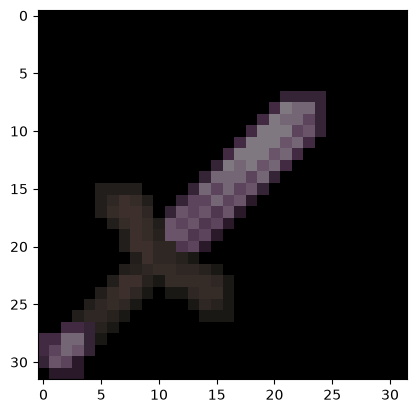

In [21]:
sample_image, _ = base_dataset[0]
print(f"Image tensor shape: {sample_image.shape}")
# (height, width, channels) = (32, 32, 3)
plt.imshow(sample_image.permute(1, 2, 0))  # Permute to (height, width, channels) for display

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = VAEConfig(
    hidden_dim=512,
    latent_dim=64,
    input_shape=(3, 32, 32),
    activation="relu",
    use_softplus_std=False,
    n_samples=1,
)
model = VAE(config).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [23]:
def run_epoch(loader: DataLoader, training: bool) -> tuple[float, float, float]:
    model.train(training)
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    with torch.set_grad_enabled(training):
        for x, _ in loader:
            x = x.to(device)
            if training:
                optimizer.zero_grad()

            mu, sigma = model.encode(x)
            std = sigmoid_to_std(sigma, model.config.use_softplus_std, eps=model.DEFAULT_EPS)
            z = model.reparameterize(mu, std)
            x_logits = model.decode(z)
            loss, loss_recon, loss_kl = compute_loss(x, x_logits, mu, sigma)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_recon += loss_recon.item()
            total_kl += loss_kl.item()

    num_batches = max(len(loader), 1)
    return total_loss / num_batches, total_recon / num_batches, total_kl / num_batches

In [32]:
epochs = 20
history = {"train_loss": [], "valid_loss": [], "train_recon": [], "valid_recon": [], "train_kl": [], "valid_kl": []}

for epoch in range(1, epochs + 1):
    train_loss, train_recon, train_kl = run_epoch(train_dataloader, training=True)
    valid_loss, valid_recon, valid_kl = run_epoch(valid_dataloader, training=False)

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["train_recon"].append(train_recon)
    history["valid_recon"].append(valid_recon)
    history["train_kl"].append(train_kl)
    history["valid_kl"].append(valid_kl)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train loss {train_loss:.4f} (recon {train_recon:.4f}, kl {train_kl:.4f}) | "
        f"valid loss {valid_loss:.4f} (recon {valid_recon:.4f}, kl {valid_kl:.4f})"
    )

Epoch 01/20 | train loss 442.3787 (recon 403.1630, kl 39.2157) | valid loss 449.0530 (recon 430.3094, kl 18.7436)
Epoch 02/20 | train loss 446.1698 (recon 411.1359, kl 35.0340) | valid loss 473.6304 (recon 456.6620, kl 16.9684)
Epoch 03/20 | train loss 449.1736 (recon 419.8153, kl 29.3583) | valid loss 457.2015 (recon 440.8634, kl 16.3381)
Epoch 04/20 | train loss 451.7844 (recon 410.1784, kl 41.6059) | valid loss 453.4293 (recon 434.5872, kl 18.8421)
Epoch 05/20 | train loss 436.6346 (recon 402.6580, kl 33.9767) | valid loss 454.9187 (recon 438.8978, kl 16.0209)
Epoch 06/20 | train loss 433.9226 (recon 401.5557, kl 32.3669) | valid loss 453.6948 (recon 435.0848, kl 18.6100)
Epoch 07/20 | train loss 430.2589 (recon 399.2383, kl 31.0206) | valid loss 457.1985 (recon 439.5726, kl 17.6259)
Epoch 08/20 | train loss 430.7969 (recon 400.7169, kl 30.0800) | valid loss 464.0672 (recon 447.2599, kl 16.8074)
Epoch 09/20 | train loss 428.4500 (recon 397.8643, kl 30.5857) | valid loss 457.3384 (re

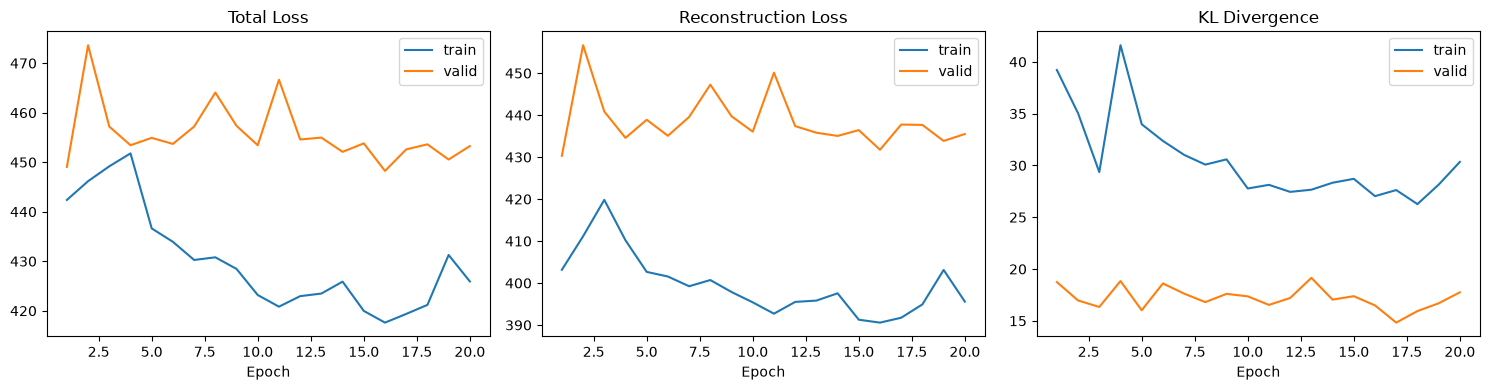

In [33]:
# --- Loss curves ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(
    axes,
    ["loss", "recon", "kl"],
    ["Total Loss", "Reconstruction Loss", "KL Divergence"],
):
    ax.plot(range(1, epochs + 1), history[f"train_{key}"], label="train")
    ax.plot(range(1, epochs + 1), history[f"valid_{key}"], label="valid")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

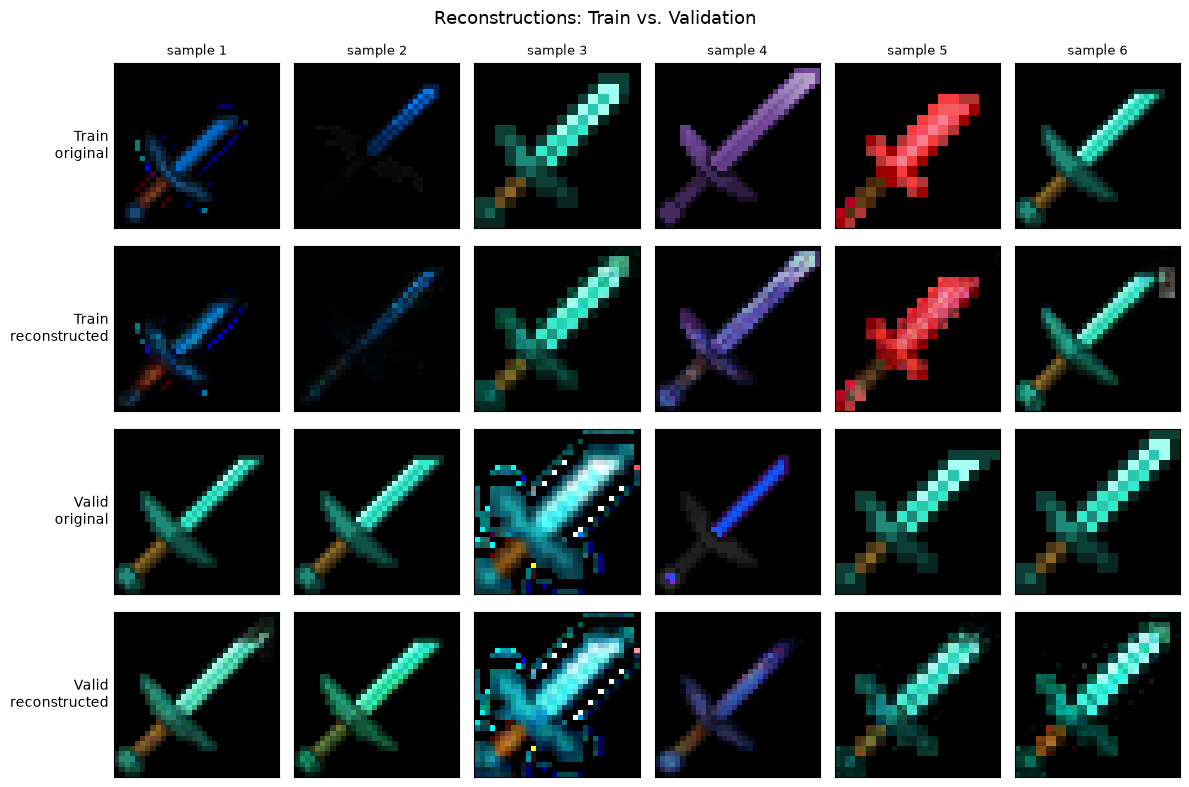

In [34]:
# --- Sample reconstructions: train vs validation ---
model.eval()


def get_samples_and_recons(loader: DataLoader, n: int) -> tuple[torch.Tensor, torch.Tensor]:
    x = torch.cat([xb for xb, _ in list(loader)[:n]]).to(device)
    with torch.no_grad():
        mu, sigma = model.encode(x)
        std = sigmoid_to_std(sigma, model.config.use_softplus_std, eps=model.DEFAULT_EPS)
        z = model.reparameterize(mu, std)
        x_recon = torch.sigmoid(model.decode(z))
    return x.cpu(), x_recon.cpu()


n_show = min(6, len(train_dataset), len(valid_dataset))
train_x, train_recon = get_samples_and_recons(train_dataloader, n_show)
valid_x, valid_recon = get_samples_and_recons(valid_dataloader, n_show)

rows = [
    ("Train\noriginal", train_x),
    ("Train\nreconstructed", train_recon),
    ("Valid\noriginal", valid_x),
    ("Valid\nreconstructed", valid_recon),
]

fig, axes = plt.subplots(len(rows), n_show, figsize=(2 * n_show, 2 * len(rows)))
for row_idx, (row_label, images) in enumerate(rows):
    for col_idx in range(n_show):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[col_idx].permute(1, 2, 0).clamp(0, 1))
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(row_label, rotation=0, ha="right", va="center", fontsize=10)
        if row_idx == 0:
            ax.set_title(f"sample {col_idx + 1}", fontsize=9)

fig.suptitle("Reconstructions: Train vs. Validation", fontsize=13)
plt.tight_layout()
plt.show()

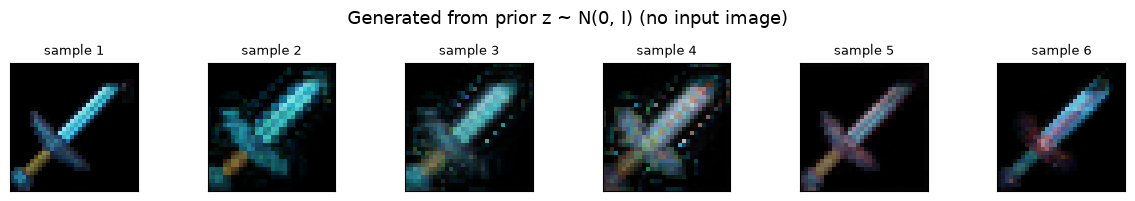

In [31]:
# --- Prior samples: decode z ~ N(0, I) directly (no input image, no encoder) ---
model.eval()

n_generate = 6
with torch.no_grad():
    z_prior = torch.randn(n_generate, config.latent_dim, device=device)
    x_generated = torch.sigmoid(model.decode(z_prior)).cpu()

fig, axes = plt.subplots(1, n_generate, figsize=(2 * n_generate, 2))
for i in range(n_generate):
    axes[i].imshow(x_generated[i].permute(1, 2, 0).clamp(0, 1))
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_title(f"sample {i + 1}", fontsize=9)

fig.suptitle("Generated from prior z ~ N(0, I) (no input image)", fontsize=13)
plt.tight_layout()
plt.show()